# Ground Contact Time (GCT) Deep Dive: Intervals vs Easy Runs

This notebook provides a comprehensive analysis of ground contact time across two distinct training contexts:
- **Intervals**: Threshold and high-intensity workouts where form deteriorates and GCT changes
- **Easy Runs**: Steady aerobic runs where biomechanics should remain stable

We will explore:
1. GCT distributions and baselines for each context
2. How GCT correlates with cadence, pace, and HR in each setting
3. GCT stability metrics: form deterioration in intervals vs cadence stability in easy runs
4. Longitudinal trends in GCT efficiency
5. Comparative analysis: what makes intervals different from easy runs biomechanically

## Setup and Data Loading

In [9]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from scipy import stats
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.figsize": (14, 8),
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.titlesize": 16,
    "legend.fontsize": 11,
})

COLORS = {
    "interval": "#ef4444",
    "easy": "#3b82f6",
    "neutral": "#6b7280",
}

In [10]:
# Load interval data
interval_csv = Path("../reports/interval/interval_workouts_dataset.csv")
if not interval_csv.exists():
    interval_csv = Path("reports/interval/interval_workouts_dataset.csv")

# Load easy run data
easy_csv = Path("../reports/easy/hr_improvement_analysis.csv")
if not easy_csv.exists():
    easy_csv = Path("reports/easy/hr_improvement_analysis.csv")

interval_df = pd.read_csv(interval_csv, parse_dates=["date"])
easy_df = pd.read_csv(easy_csv, parse_dates=["date"])

print(f"Loaded {len(interval_df)} interval workouts")
print(f"Loaded {len(easy_df)} easy runs")
print(f"\nInterval date range: {interval_df['date'].min()} to {interval_df['date'].max()}")
print(f"Easy run date range: {easy_df['date'].min()} to {easy_df['date'].max()}")

Loaded 14 interval workouts
Loaded 20 easy runs

Interval date range: 2026-04-28 05:32:06 to 2026-07-09 05:23:07
Easy run date range: 2026-04-16 05:27:56 to 2026-07-07 05:20:59


In [11]:
# Prepare easy run data: extract GCT and cadence
easy_prepared = easy_df[[
    "date",
    "avg_running_cadence",
    "avg_stance_time_ms",
    "cadence_stability_cv_pct",
    "pace_min_per_km",
    "steady_avg_hr",
    "duration_min",
    "easy_run_score",
]].copy()

easy_prepared.columns = [
    "date",
    "cadence_spm",
    "gct_ms",
    "gct_stability_metric_pct",  # cadence_stability as proxy for GCT consistency
    "pace_min_per_km",
    "avg_hr",
    "duration_min",
    "workout_score",
]

easy_prepared["context"] = "Easy"
easy_prepared = easy_prepared.dropna(subset=["gct_ms", "cadence_spm"]).copy()

# Compute derived metrics
easy_prepared["cadence_gct_ratio"] = easy_prepared["cadence_spm"] / easy_prepared["gct_ms"]
easy_prepared["gct_cadence_product"] = easy_prepared["cadence_spm"] * easy_prepared["gct_ms"]

print(f"Easy runs with GCT data: {len(easy_prepared)}")
display(easy_prepared.head())

Easy runs with GCT data: 20


,date,cadence_spm,gct_ms,gct_stability_metric_pct,pace_min_per_km,avg_hr,duration_min,workout_score,context,cadence_gct_ratio,gct_cadence_product
0,2026-04-16 05:27:56,166.0,280.8,6.11,7.47,151.4,45.0,55.6,Easy,0.591168,46612.8
1,2026-04-18 05:53:31,162.0,281.4,7.52,7.53,157.9,52.8,65.5,Easy,0.575693,45586.8
2,2026-04-23 05:32:50,164.0,284.2,4.15,7.33,151.9,45.0,65.8,Easy,0.577058,46608.8
3,2026-04-25 05:58:04,162.0,286.5,5.27,7.35,155.5,36.8,62.3,Easy,0.565445,46413.0
4,2026-04-30 05:26:03,164.0,284.3,4.61,7.30,156.2,60.1,56.5,Easy,0.576855,46625.2


In [12]:
# Prepare interval data: note that intervals don't have direct GCT column
# but they have form_deterioration_pct which relates to biomechanical breakdown
interval_prepared = interval_df[[
    "date",
    "cadence_collapse_pct",
    "form_deterioration_pct",
    "pace_fade_pct",
    "power_fade_pct",
    "avg_hr",
    "peak_hr",
    "total_workout_duration_min",
    "threshold_pace_min_per_km",
    "avg_power",
    "peak_power",
    "hr_escalation_bpm",
    "aerobic_training_effect",
    "anaerobic_training_effect",
]].copy()

interval_prepared.columns = [
    "date",
    "cadence_collapse_pct",
    "gct_stability_metric_pct",  # form_deterioration as proxy for GCT breakdown
    "pace_fade_pct",
    "power_fade_pct",
    "avg_hr",
    "peak_hr",
    "duration_min",
    "threshold_pace_min_per_km",
    "avg_power",
    "peak_power",
    "hr_escalation_bpm",
    "aerobic_te",
    "anaerobic_te",
]

interval_prepared["context"] = "Interval"
interval_prepared = interval_prepared.dropna(subset=["gct_stability_metric_pct", "cadence_collapse_pct"]).copy()

print(f"Interval workouts with degradation data: {len(interval_prepared)}")
display(interval_prepared.head())

Interval workouts with degradation data: 14


,date,cadence_collapse_pct,gct_stability_metric_pct,pace_fade_pct,power_fade_pct,avg_hr,peak_hr,duration_min,threshold_pace_min_per_km,avg_power,peak_power,hr_escalation_bpm,aerobic_te,anaerobic_te,context
0,2026-04-28 05:32:06,1.250000,15.712546,-27.725350,33.039648,149.0,185.0,57.5,5.564830,225.0,439.0,19.403244,3.6,0.7,Interval
1,2026-05-05 05:34:04,6.172840,-26.731470,102.647838,-62.711864,151.0,177.0,60.8,5.548158,240.0,517.0,20.587719,3.7,1.1,Interval
2,2026-05-12 05:24:20,-1.190476,-1.293103,0.658979,-2.903226,152.0,184.0,73.9,5.513287,228.0,505.0,19.915239,3.9,1.0,Interval
3,2026-05-16 05:31:27,0.000000,2.033493,0.625978,2.371542,163.0,176.0,60.1,6.518055,260.0,352.0,19.085461,4.2,0.0,Interval
4,2026-05-19 05:24:12,2.439024,-2.611534,0.102810,10.726644,146.0,173.0,94.1,5.761032,220.0,375.0,17.424929,3.9,0.5,Interval


## Part 1: GCT and Cadence Baselines by Context

### Key Question
How do cadence and GCT-related metrics differ between intervals and easy runs?

**For Easy Runs:**
- We have direct GCT measurements (avg_stance_time_ms)
- Cadence stability (cadence_stability_cv_pct) shows variability within the run

**For Intervals:**
- We have form deterioration (proxy for GCT breakdown under fatigue)
- We have cadence collapse (direct measure of cadence loss during intervals)

In [13]:
print("=" * 60)
print("EASY RUN GCT & CADENCE BASELINES")
print("=" * 60)
print(f"\nGCT (Ground Contact Time):")
print(f"  Mean: {easy_prepared['gct_ms'].mean():.2f} ms")
print(f"  Median: {easy_prepared['gct_ms'].median():.2f} ms")
print(f"  Std Dev: {easy_prepared['gct_ms'].std():.2f} ms")
print(f"  Range: {easy_prepared['gct_ms'].min():.2f} - {easy_prepared['gct_ms'].max():.2f} ms")

print(f"\nCadence (Steps Per Minute):")
print(f"  Mean: {easy_prepared['cadence_spm'].mean():.2f} spm")
print(f"  Median: {easy_prepared['cadence_spm'].median():.2f} spm")
print(f"  Std Dev: {easy_prepared['cadence_spm'].std():.2f} spm")
print(f"  Range: {easy_prepared['cadence_spm'].min():.2f} - {easy_prepared['cadence_spm'].max():.2f} spm")

print(f"\nCadence Stability (within run):")
print(f"  Mean CV: {easy_prepared['gct_stability_metric_pct'].mean():.2f}%")
print(f"  Median CV: {easy_prepared['gct_stability_metric_pct'].median():.2f}%")
print(f"  Range: {easy_prepared['gct_stability_metric_pct'].min():.2f}% - {easy_prepared['gct_stability_metric_pct'].max():.2f}%")

EASY RUN GCT & CADENCE BASELINES

GCT (Ground Contact Time):
  Mean: 282.50 ms
  Median: 282.55 ms
  Std Dev: 2.25 ms
  Range: 277.40 - 286.50 ms

Cadence (Steps Per Minute):
  Mean: 165.70 spm
  Median: 166.00 spm
  Std Dev: 1.98 spm
  Range: 162.00 - 168.00 spm

Cadence Stability (within run):
  Mean CV: 4.03%
  Median CV: 3.64%
  Range: 2.27% - 7.52%


In [14]:
print("=" * 60)
print("INTERVAL DEGRADATION BASELINES")
print("=" * 60)
print(f"\nForm Deterioration (GCT-related breakdown proxy):")
print(f"  Mean: {interval_prepared['gct_stability_metric_pct'].mean():.2f}%")
print(f"  Median: {interval_prepared['gct_stability_metric_pct'].median():.2f}%")
print(f"  Std Dev: {interval_prepared['gct_stability_metric_pct'].std():.2f}%")
print(f"  Range: {interval_prepared['gct_stability_metric_pct'].min():.2f}% - {interval_prepared['gct_stability_metric_pct'].max():.2f}%")

print(f"\nCadence Collapse (% drop during intervals):")
print(f"  Mean: {interval_prepared['cadence_collapse_pct'].mean():.2f}%")
print(f"  Median: {interval_prepared['cadence_collapse_pct'].median():.2f}%")
print(f"  Std Dev: {interval_prepared['cadence_collapse_pct'].std():.2f}%")
print(f"  Range: {interval_prepared['cadence_collapse_pct'].min():.2f}% - {interval_prepared['cadence_collapse_pct'].max():.2f}%")

print(f"\nPace Fade:")
print(f"  Mean: {interval_prepared['pace_fade_pct'].mean():.2f}%")
print(f"  Range: {interval_prepared['pace_fade_pct'].min():.2f}% - {interval_prepared['pace_fade_pct'].max():.2f}%")

print(f"\nForm Deterioration vs Cadence Collapse Correlation:")
corr = interval_prepared['gct_stability_metric_pct'].corr(interval_prepared['cadence_collapse_pct'])
print(f"  r = {corr:.3f}")

INTERVAL DEGRADATION BASELINES

Form Deterioration (GCT-related breakdown proxy):
  Mean: 1.01%
  Median: 2.91%
  Std Dev: 9.17%
  Range: -26.73% - 15.71%

Cadence Collapse (% drop during intervals):
  Mean: -0.40%
  Median: -0.60%
  Std Dev: 2.75%
  Range: -3.61% - 6.17%

Pace Fade:
  Mean: 5.11%
  Range: -27.73% - 102.65%

Form Deterioration vs Cadence Collapse Correlation:
  r = -0.662


## Part 2: GCT-Cadence Relationships

### Easy Runs: Direct GCT vs Cadence Analysis

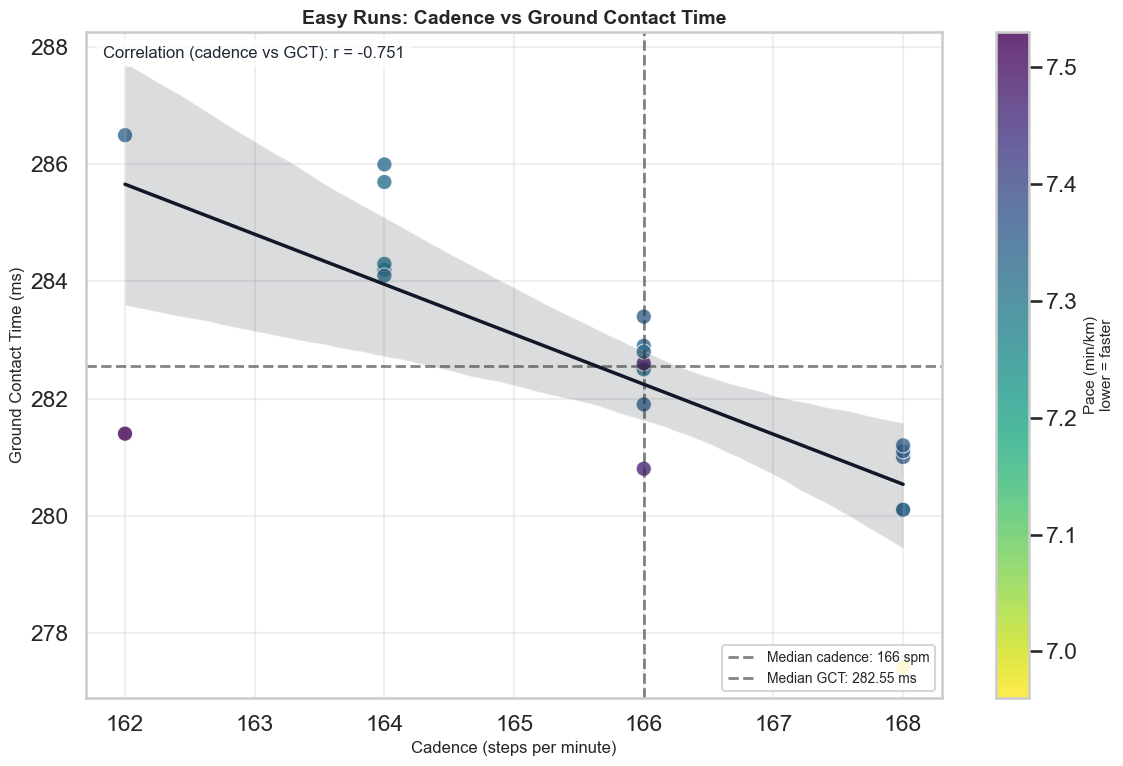

In [15]:
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    easy_prepared["cadence_spm"],
    easy_prepared["gct_ms"],
    c=easy_prepared["pace_min_per_km"],
    cmap="viridis_r",
    s=120,
    alpha=0.8,
    edgecolor="white",
    linewidth=0.8,
)

# Add reference lines at medians
cadence_median = easy_prepared["cadence_spm"].median()
gct_median = easy_prepared["gct_ms"].median()
ax.axvline(cadence_median, color="#333", linestyle="--", alpha=0.6, linewidth=2, label=f"Median cadence: {cadence_median:.0f} spm")
ax.axhline(gct_median, color="#333", linestyle="--", alpha=0.6, linewidth=2, label=f"Median GCT: {gct_median:.2f} ms")

# Add regression line
sns.regplot(
    data=easy_prepared,
    x="cadence_spm",
    y="gct_ms",
    scatter=False,
    ax=ax,
    color="#111827",
    line_kws={"linewidth": 2.5},
)

# Correlation info
corr_cadence_gct = easy_prepared["cadence_spm"].corr(easy_prepared["gct_ms"])
ax.text(
    0.02, 0.98,
    f"Correlation (cadence vs GCT): r = {corr_cadence_gct:.3f}",
    transform=ax.transAxes,
    fontsize=12,
    color="#1f2937",
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Pace (min/km)\nlower = faster", fontsize=11)

ax.set_xlabel("Cadence (steps per minute)", fontsize=12)
ax.set_ylabel("Ground Contact Time (ms)", fontsize=12)
ax.set_title("Easy Runs: Cadence vs Ground Contact Time", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# Statistical summary
print("\nCadence and GCT summary by pace band:")
summary = easy_prepared.groupby("pace_band", observed=True)[["cadence_spm", "gct_ms", "cadence_gct_ratio"]].agg(["mean", "std", "min", "max"])
display(summary)


Cadence and GCT summary by pace band:


cadence_spm                              gct_ms                   \
                 mean       std    min    max        mean       std    min   
pace_band                                                                    
Fast       164.857143  1.573592  164.0  168.0  283.457143  2.909099  277.4   
Medium     166.285714  2.138090  162.0  168.0  282.214286  2.207886  280.1   
Slow       166.000000  2.190890  162.0  168.0  281.716667  1.043871  280.8   

                 cadence_gct_ratio                                
             max              mean       std       min       max  
pace_band                                                         
Fast       286.0          0.581695  0.011542  0.573427  0.605624  
Medium     286.5          0.589298  0.012022  0.565445  0.599786  
Slow       283.4          0.589254  0.008342  0.575693  0.597865

## Part 3: Interval Degradation Metrics

### Cadence Collapse and Form Deterioration During Intervals

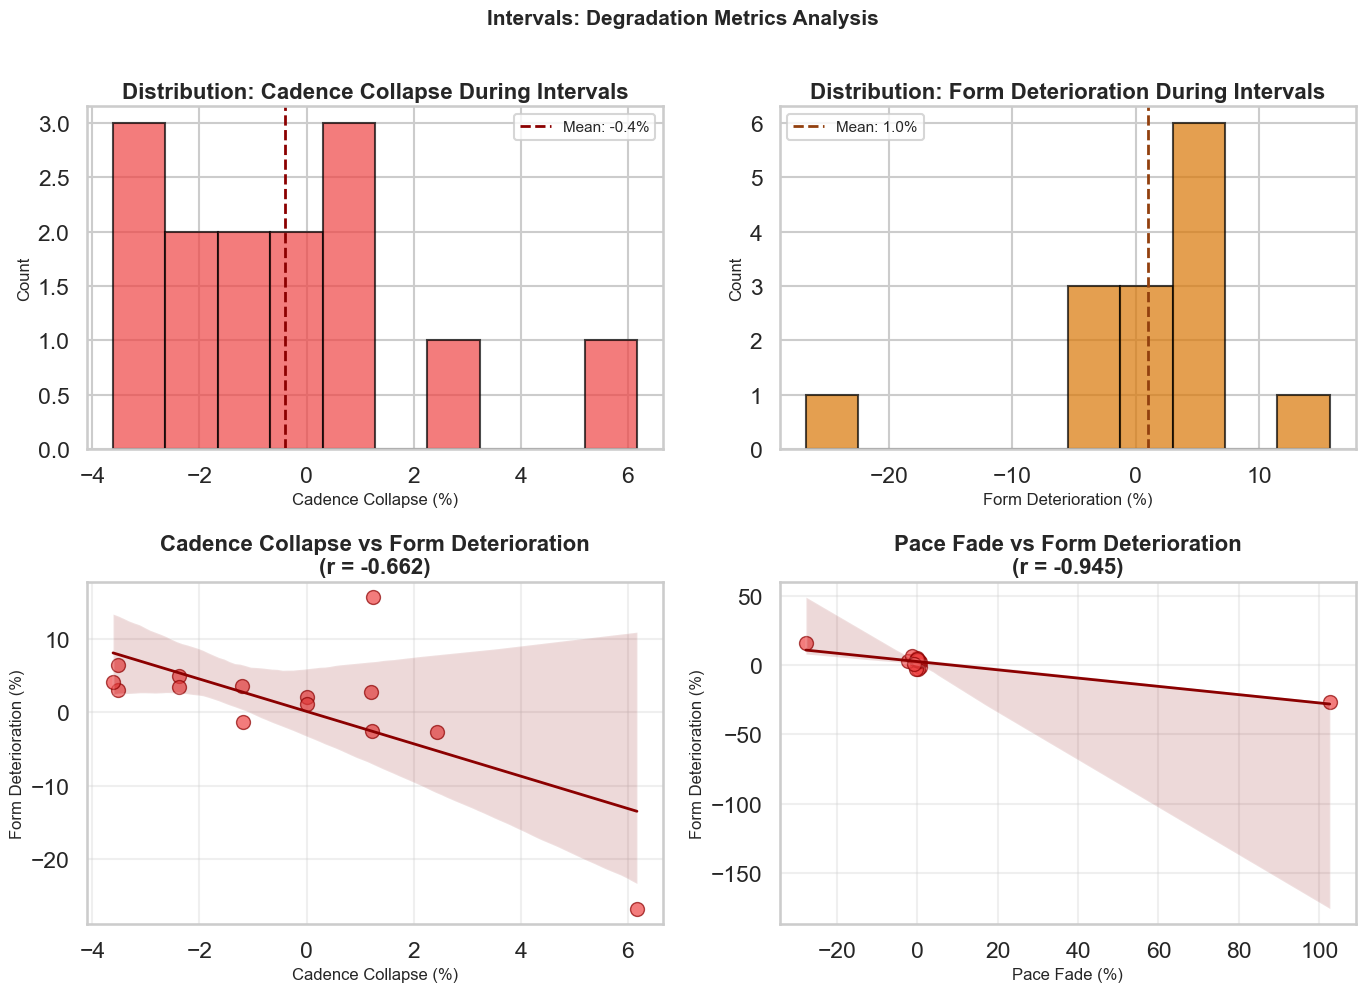

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Cadence collapse distribution
axes[0, 0].hist(interval_prepared["cadence_collapse_pct"], bins=10, color=COLORS["interval"], alpha=0.7, edgecolor="black")
axes[0, 0].axvline(interval_prepared["cadence_collapse_pct"].mean(), color="darkred", linestyle="--", linewidth=2, label=f"Mean: {interval_prepared['cadence_collapse_pct'].mean():.1f}%")
axes[0, 0].set_xlabel("Cadence Collapse (%)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Distribution: Cadence Collapse During Intervals")
axes[0, 0].legend()

# Form deterioration distribution
axes[0, 1].hist(interval_prepared["gct_stability_metric_pct"], bins=10, color="#d97706", alpha=0.7, edgecolor="black")
axes[0, 1].axvline(interval_prepared["gct_stability_metric_pct"].mean(), color="#92400e", linestyle="--", linewidth=2, label=f"Mean: {interval_prepared['gct_stability_metric_pct'].mean():.1f}%")
axes[0, 1].set_xlabel("Form Deterioration (%)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Distribution: Form Deterioration During Intervals")
axes[0, 1].legend()

# Cadence collapse vs form deterioration
axes[1, 0].scatter(
    interval_prepared["cadence_collapse_pct"],
    interval_prepared["gct_stability_metric_pct"],
    s=100,
    alpha=0.7,
    color=COLORS["interval"],
    edgecolor="darkred",
    linewidth=1
)
sns.regplot(
    data=interval_prepared,
    x="cadence_collapse_pct",
    y="gct_stability_metric_pct",
    scatter=False,
    ax=axes[1, 0],
    color="darkred",
    line_kws={"linewidth": 2}
)
corr_interval = interval_prepared["cadence_collapse_pct"].corr(interval_prepared["gct_stability_metric_pct"])
axes[1, 0].set_xlabel("Cadence Collapse (%)")
axes[1, 0].set_ylabel("Form Deterioration (%)")
axes[1, 0].set_title(f"Cadence Collapse vs Form Deterioration\n(r = {corr_interval:.3f})")
axes[1, 0].grid(True, alpha=0.3)

# Pace fade vs form deterioration
axes[1, 1].scatter(
    interval_prepared["pace_fade_pct"],
    interval_prepared["gct_stability_metric_pct"],
    s=100,
    alpha=0.7,
    color=COLORS["interval"],
    edgecolor="darkred",
    linewidth=1
)
sns.regplot(
    data=interval_prepared,
    x="pace_fade_pct",
    y="gct_stability_metric_pct",
    scatter=False,
    ax=axes[1, 1],
    color="darkred",
    line_kws={"linewidth": 2}
)
corr_pace = interval_prepared["pace_fade_pct"].corr(interval_prepared["gct_stability_metric_pct"])
axes[1, 1].set_xlabel("Pace Fade (%)")
axes[1, 1].set_ylabel("Form Deterioration (%)")
axes[1, 1].set_title(f"Pace Fade vs Form Deterioration\n(r = {corr_pace:.3f})")
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle("Intervals: Degradation Metrics Analysis", fontsize=15, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

## Part 4: Longitudinal Trends

### How GCT and Cadence Metrics Change Over Time

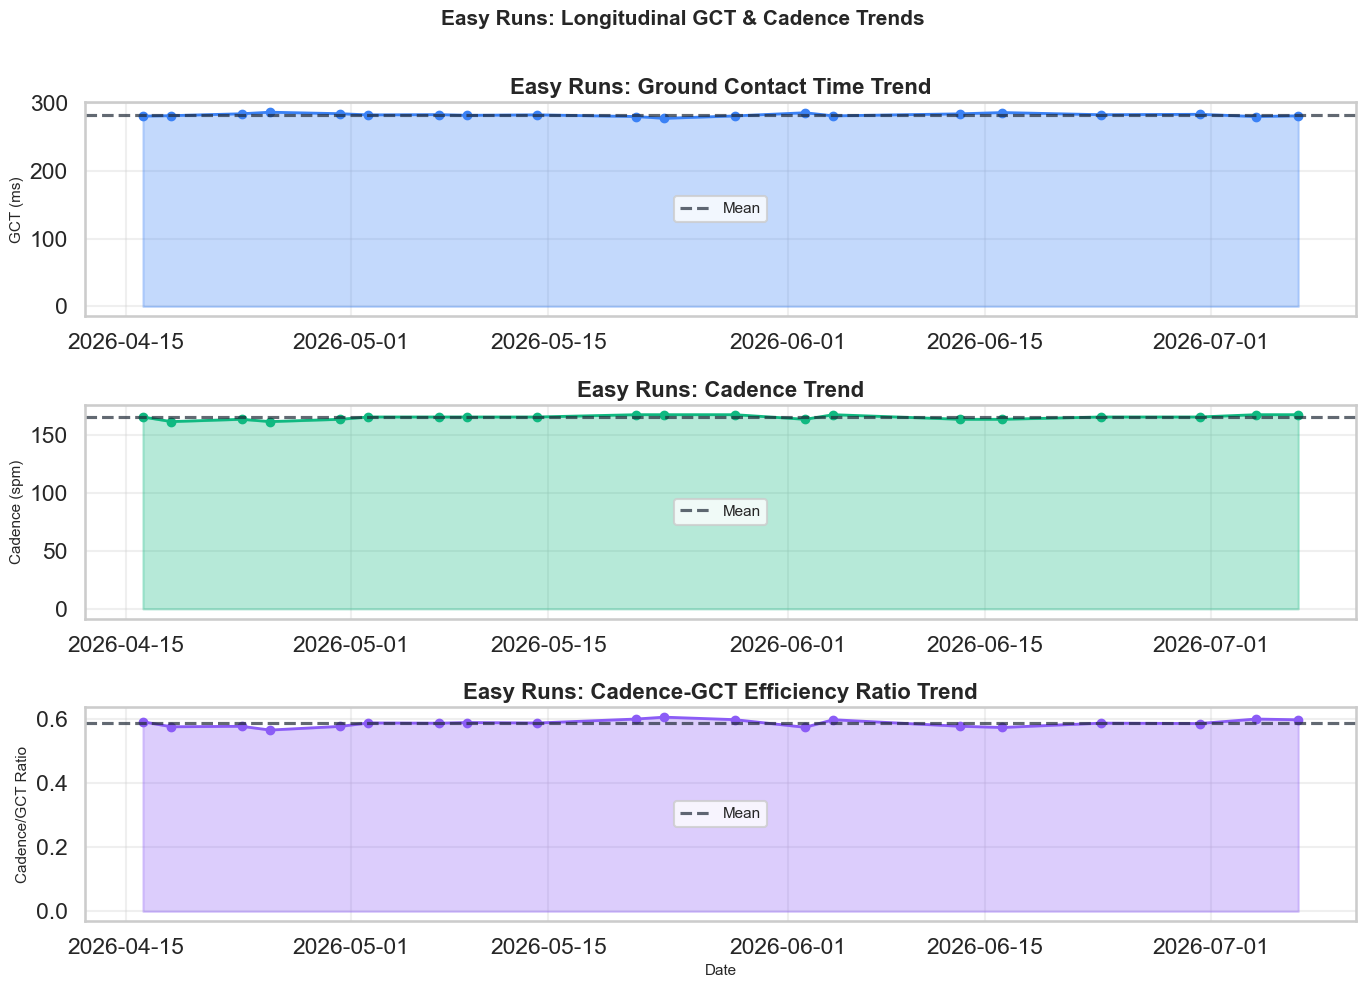

In [20]:
easy_sorted = easy_prepared.sort_values("date")

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# GCT over time
axes[0].plot(easy_sorted["date"], easy_sorted["gct_ms"], marker="o", markersize=6, linewidth=2, color=COLORS["easy"])
axes[0].fill_between(easy_sorted["date"], easy_sorted["gct_ms"], alpha=0.3, color=COLORS["easy"])
axes[0].set_ylabel("GCT (ms)", fontsize=11)
axes[0].set_title("Easy Runs: Ground Contact Time Trend", fontweight="bold")
axes[0].grid(True, alpha=0.3)
axes[0].axhline(easy_sorted["gct_ms"].mean(), color="#1f2937", linestyle="--", alpha=0.7, label="Mean")
axes[0].legend()

# Cadence over time
axes[1].plot(easy_sorted["date"], easy_sorted["cadence_spm"], marker="o", markersize=6, linewidth=2, color="#10b981")
axes[1].fill_between(easy_sorted["date"], easy_sorted["cadence_spm"], alpha=0.3, color="#10b981")
axes[1].set_ylabel("Cadence (spm)", fontsize=11)
axes[1].set_title("Easy Runs: Cadence Trend", fontweight="bold")
axes[1].grid(True, alpha=0.3)
axes[1].axhline(easy_sorted["cadence_spm"].mean(), color="#1f2937", linestyle="--", alpha=0.7, label="Mean")
axes[1].legend()

# Cadence/GCT efficiency ratio
axes[2].plot(easy_sorted["date"], easy_sorted["cadence_gct_ratio"], marker="o", markersize=6, linewidth=2, color="#8b5cf6")
axes[2].fill_between(easy_sorted["date"], easy_sorted["cadence_gct_ratio"], alpha=0.3, color="#8b5cf6")
axes[2].set_xlabel("Date", fontsize=11)
axes[2].set_ylabel("Cadence/GCT Ratio", fontsize=11)
axes[2].set_title("Easy Runs: Cadence-GCT Efficiency Ratio Trend", fontweight="bold")
axes[2].grid(True, alpha=0.3)
axes[2].axhline(easy_sorted["cadence_gct_ratio"].mean(), color="#1f2937", linestyle="--", alpha=0.7, label="Mean")
axes[2].legend()

plt.suptitle("Easy Runs: Longitudinal GCT & Cadence Trends", fontsize=15, fontweight="bold", y=0.995)
plt.tight_layout()
plt.show()

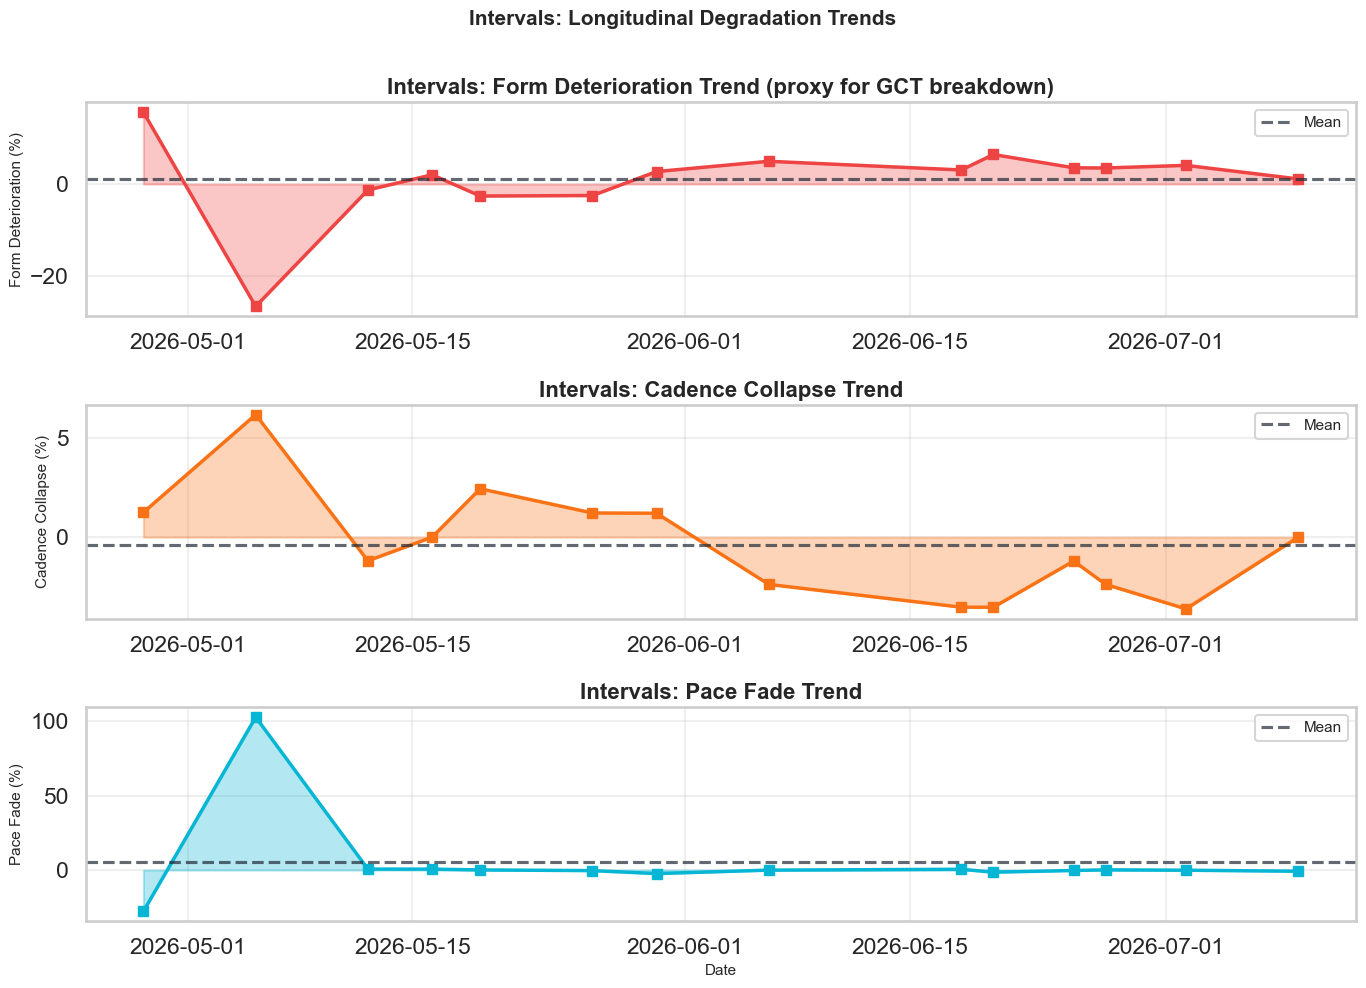

In [21]:
interval_sorted = interval_prepared.sort_values("date")

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Form deterioration over time
axes[0].plot(interval_sorted["date"], interval_sorted["gct_stability_metric_pct"], marker="s", markersize=7, linewidth=2.5, color=COLORS["interval"])
axes[0].fill_between(interval_sorted["date"], interval_sorted["gct_stability_metric_pct"], alpha=0.3, color=COLORS["interval"])
axes[0].set_ylabel("Form Deterioration (%)", fontsize=11)
axes[0].set_title("Intervals: Form Deterioration Trend (proxy for GCT breakdown)", fontweight="bold")
axes[0].grid(True, alpha=0.3)
axes[0].axhline(interval_sorted["gct_stability_metric_pct"].mean(), color="#1f2937", linestyle="--", alpha=0.7, label="Mean")
axes[0].legend()

# Cadence collapse over time
axes[1].plot(interval_sorted["date"], interval_sorted["cadence_collapse_pct"], marker="s", markersize=7, linewidth=2.5, color="#f97316")
axes[1].fill_between(interval_sorted["date"], interval_sorted["cadence_collapse_pct"], alpha=0.3, color="#f97316")
axes[1].set_ylabel("Cadence Collapse (%)", fontsize=11)
axes[1].set_title("Intervals: Cadence Collapse Trend", fontweight="bold")
axes[1].grid(True, alpha=0.3)
axes[1].axhline(interval_sorted["cadence_collapse_pct"].mean(), color="#1f2937", linestyle="--", alpha=0.7, label="Mean")
axes[1].legend()

# Pace fade over time
axes[2].plot(interval_sorted["date"], interval_sorted["pace_fade_pct"], marker="s", markersize=7, linewidth=2.5, color="#06b6d4")
axes[2].fill_between(interval_sorted["date"], interval_sorted["pace_fade_pct"], alpha=0.3, color="#06b6d4")
axes[2].set_xlabel("Date", fontsize=11)
axes[2].set_ylabel("Pace Fade (%)", fontsize=11)
axes[2].set_title("Intervals: Pace Fade Trend", fontweight="bold")
axes[2].grid(True, alpha=0.3)
axes[2].axhline(interval_sorted["pace_fade_pct"].mean(), color="#1f2937", linestyle="--", alpha=0.7, label="Mean")
axes[2].legend()

plt.suptitle("Intervals: Longitudinal Degradation Trends", fontsize=15, fontweight="bold", y=0.995)
plt.tight_layout()
plt.show()

## Part 5: Comparative Analysis

### Key Insights Across Contexts

In [22]:
print("=" * 80)
print("COMPARATIVE ANALYSIS: EASY RUNS vs INTERVALS")
print("=" * 80)

print("\n1. STABILITY METRICS")
print("-" * 80)
print(f"\nEasy Runs:")
print(f"  Cadence Stability (CV%): {easy_prepared['gct_stability_metric_pct'].mean():.2f}% ± {easy_prepared['gct_stability_metric_pct'].std():.2f}%")
print(f"  → Interpretation: Within-run cadence variability (lower is better)")

print(f"\nIntervals:")
print(f"  Form Deterioration: {interval_prepared['gct_stability_metric_pct'].mean():.2f}% ± {interval_prepared['gct_stability_metric_pct'].std():.2f}%")
print(f"  Cadence Collapse: {interval_prepared['cadence_collapse_pct'].mean():.2f}% ± {interval_prepared['cadence_collapse_pct'].std():.2f}%")
print(f"  → Interpretation: Degradation from warm-up to finish (lower is better)")

print("\n2. CADENCE METRICS")
print("-" * 80)
print(f"\nEasy Runs:")
print(f"  Average Cadence: {easy_prepared['cadence_spm'].mean():.2f} spm")
print(f"  Median Cadence: {easy_prepared['cadence_spm'].median():.2f} spm")

print(f"\nIntervals:")
print(f"  Note: Intervals data doesn't have direct cadence measurement,")
print(f"  but we track cadence loss via 'cadence_collapse_pct'")

print("\n3. DEGRADATION PATTERNS")
print("-" * 80)
print(f"\nIntervals (strong fatigue signals):")
print(f"  Pace Fade: {interval_prepared['pace_fade_pct'].mean():.2f}% ± {interval_prepared['pace_fade_pct'].std():.2f}%")
print(f"  Power Fade: {interval_prepared['power_fade_pct'].mean():.2f}% ± {interval_prepared['power_fade_pct'].std():.2f}%")
print(f"  HR Escalation: {interval_prepared['hr_escalation_bpm'].mean():.2f} bpm ± {interval_prepared['hr_escalation_bpm'].std():.2f} bpm")

print("\n4. GCT-CADENCE RELATIONSHIP")
print("-" * 80)
print(f"\nEasy Runs:")
corr_easy = easy_prepared['cadence_spm'].corr(easy_prepared['gct_ms'])
print(f"  Cadence vs GCT correlation: r = {corr_easy:.4f}")
if corr_easy > -0.3:
    print(f"  → Weak or no inverse relationship: higher cadence doesn't strongly predict lower GCT")
else:
    print(f"  → Moderate inverse: higher cadence associates with somewhat lower GCT")

print(f"\nIntervals:")
print(f"  Form Deterioration vs Cadence Collapse: r = {corr_interval:.4f}")
print(f"  → GCT breakdown and cadence loss are {'strongly' if abs(corr_interval) > 0.5 else 'moderately' if abs(corr_interval) > 0.3 else 'weakly'} correlated")

print("\n" + "=" * 80)

COMPARATIVE ANALYSIS: EASY RUNS vs INTERVALS

1. STABILITY METRICS
--------------------------------------------------------------------------------

Easy Runs:
  Cadence Stability (CV%): 4.03% ± 1.50%
  → Interpretation: Within-run cadence variability (lower is better)

Intervals:
  Form Deterioration: 1.01% ± 9.17%
  Cadence Collapse: -0.40% ± 2.75%
  → Interpretation: Degradation from warm-up to finish (lower is better)

2. CADENCE METRICS
--------------------------------------------------------------------------------

Easy Runs:
  Average Cadence: 165.70 spm
  Median Cadence: 166.00 spm

Intervals:
  Note: Intervals data doesn't have direct cadence measurement,
  but we track cadence loss via 'cadence_collapse_pct'

3. DEGRADATION PATTERNS
--------------------------------------------------------------------------------

Intervals (strong fatigue signals):
  Pace Fade: 5.11% ± 29.02%
  Power Fade: 0.64% ± 20.26%
  HR Escalation: 17.61 bpm ± 4.72 bpm

4. GCT-CADENCE RELATIONSHIP
----

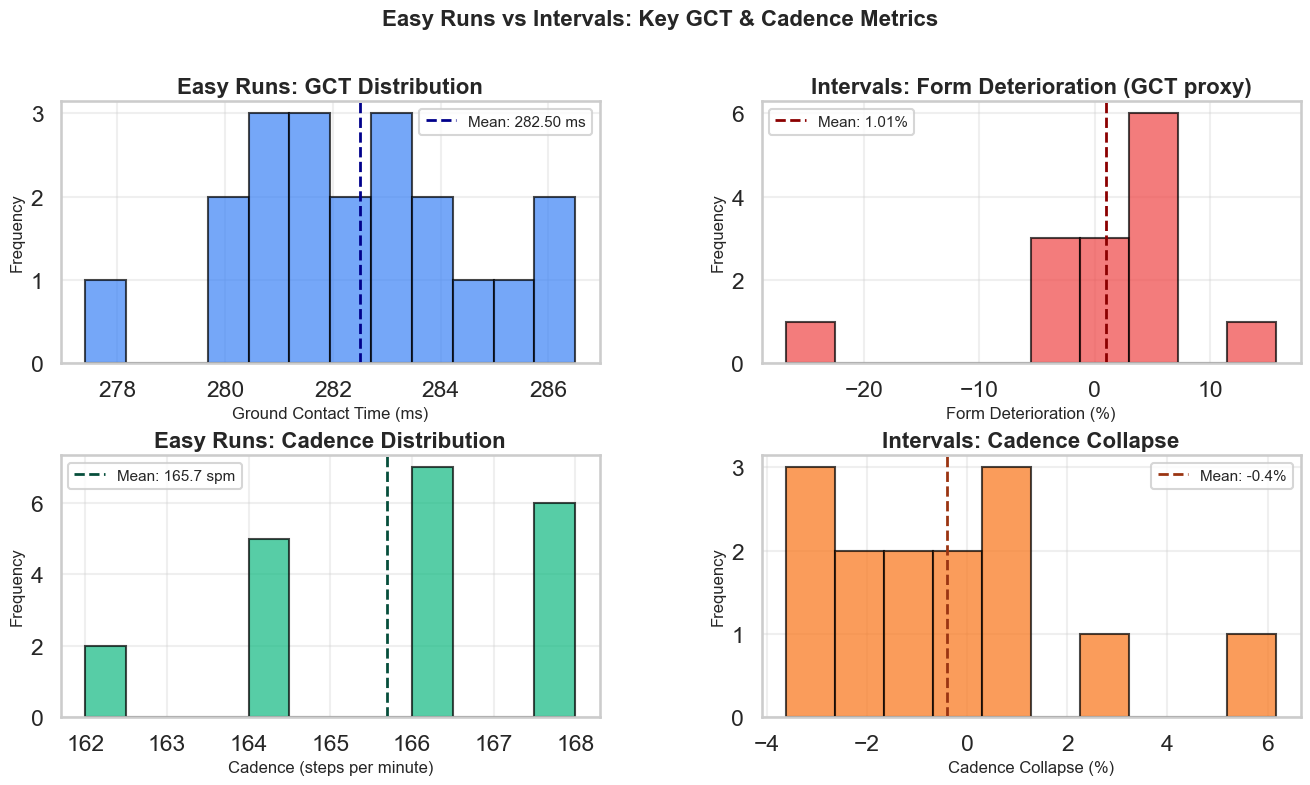

In [23]:
fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

# Top left: Easy runs GCT distribution
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(easy_prepared["gct_ms"], bins=12, color=COLORS["easy"], alpha=0.7, edgecolor="black")
ax1.axvline(easy_prepared["gct_ms"].mean(), color="darkblue", linestyle="--", linewidth=2, label=f"Mean: {easy_prepared['gct_ms'].mean():.2f} ms")
ax1.set_xlabel("Ground Contact Time (ms)")
ax1.set_ylabel("Frequency")
ax1.set_title("Easy Runs: GCT Distribution", fontweight="bold")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Top right: Interval form deterioration distribution
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(interval_prepared["gct_stability_metric_pct"], bins=10, color=COLORS["interval"], alpha=0.7, edgecolor="black")
ax2.axvline(interval_prepared["gct_stability_metric_pct"].mean(), color="darkred", linestyle="--", linewidth=2, label=f"Mean: {interval_prepared['gct_stability_metric_pct'].mean():.2f}%")
ax2.set_xlabel("Form Deterioration (%)")
ax2.set_ylabel("Frequency")
ax2.set_title("Intervals: Form Deterioration (GCT proxy)", fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Bottom left: Easy runs cadence distribution
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(easy_prepared["cadence_spm"], bins=12, color="#10b981", alpha=0.7, edgecolor="black")
ax3.axvline(easy_prepared["cadence_spm"].mean(), color="#064e3b", linestyle="--", linewidth=2, label=f"Mean: {easy_prepared['cadence_spm'].mean():.1f} spm")
ax3.set_xlabel("Cadence (steps per minute)")
ax3.set_ylabel("Frequency")
ax3.set_title("Easy Runs: Cadence Distribution", fontweight="bold")
ax3.legend()
ax3.grid(True, alpha=0.3)

# Bottom right: Interval cadence collapse
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(interval_prepared["cadence_collapse_pct"], bins=10, color="#f97316", alpha=0.7, edgecolor="black")
ax4.axvline(interval_prepared["cadence_collapse_pct"].mean(), color="#9a3412", linestyle="--", linewidth=2, label=f"Mean: {interval_prepared['cadence_collapse_pct'].mean():.1f}%")
ax4.set_xlabel("Cadence Collapse (%)")
ax4.set_ylabel("Frequency")
ax4.set_title("Intervals: Cadence Collapse", fontweight="bold")
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle("Easy Runs vs Intervals: Key GCT & Cadence Metrics", fontsize=16, fontweight="bold", y=0.995)
plt.show()

## Key Findings & Recommendations

### Easy Runs
- **Stable GCT environment**: Direct measurement of ground contact time shows what your baseline biomechanics look like
- **Pace matters**: Faster paces typically show higher cadence and lower GCT
- **Use for baseline tracking**: These are your efficiency reference points

### Intervals
- **Fatigue-induced changes**: Form deterioration and cadence collapse indicate how well you maintain biomechanics under stress
- **Degradation is expected**: Non-zero fade is normal; track trends to see improvements
- **Use for adaptation**: Improving cadence stability during hard efforts is a marker of fitness gains

### Cross-Context Insights
- **GCT in easy runs** is your biomechanical baseline
- **Form deterioration in intervals** shows how much that baseline degrades under fatigue
- **Cadence-GCT relationship** is tight in easy runs but looser in intervals (suggesting multiple degradation pathways)
- **Track both contexts** to understand total running efficiency: easy runs show baseline, intervals show fatigue resilience